# 01b — Contrôle qualité des métriques générées

À exécuter après le notebook `01_generer_csv_<corpus>.ipynb`. Le corpus est
sélectionné dans la cellule de configuration ; aucun CSV d'un autre corpus n'est
mélangé automatiquement.


## 1. Configuration


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from metric_registry import get_dataset
from pipeline_utils import detect_project_dir, metric_inventory, aggregate_metrics

PROJECT_DIR = detect_project_dir()
DATASET = "Mirabelle"  # "Mirabelle", "Nowledgeable" ou "Progsnap2"
JOIN_MODE = "outer"

SPEC = get_dataset(DATASET)
CSV_DIR = SPEC.csv_dir(PROJECT_DIR)
print("Corpus :", DATASET)
print("CSV    :", CSV_DIR)


Corpus : Mirabelle
CSV    : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine nettoyée\Chaine_nettoyee\csv\Mirabelle


## 2. Inventaire


In [2]:
inventory_df = metric_inventory(CSV_DIR)
if inventory_df.empty:
    raise FileNotFoundError(f"Aucune métrique dans {CSV_DIR}. Exécutez d'abord le notebook 01 correspondant.")
display(inventory_df)


,fichier,statut,lignes,colonnes,variables
0,attempts_to_first_success.csv,ok,46,2,AttemptsToFirstSuccess
1,code_change_magnitude.csv,ok,38,2,CodeChangeMagnitude
2,error_quotient.csv,ok,39,2,ErrorQuotient
3,error_quotient_fe.csv,ok,39,2,ErrorQuotient_FE
4,exception_run_ratio.csv,ok,47,2,ExceptionTestRunRatio
5,failed_run_ratio.csv,ok,47,2,FailedTestRunRatio
6,first_attempt_success_rate.csv,ok,47,2,FirstAttemptSuccessRate
7,function_coverage.csv,ok,49,2,FunctionCoverage
8,productive_transition_rate.csv,ok,37,2,ProductiveTransitionRate
9,red.csv,ok,39,2,RED


## 3. Agrégation par étudiant


In [3]:
features, load_report = aggregate_metrics(CSV_DIR, join_mode=JOIN_MODE)
display(load_report)
print(f"Table agrégée : {features.shape[0]} étudiant(s) × {features.shape[1]-1} métrique(s)")
display(features.head())


,fichier,statut,raison,lignes,variables
0,attempts_to_first_success.csv,chargé,,46,AttemptsToFirstSuccess
1,code_change_magnitude.csv,chargé,,38,CodeChangeMagnitude
2,error_quotient.csv,chargé,,39,ErrorQuotient
3,error_quotient_fe.csv,chargé,,39,ErrorQuotient_FE
4,exception_run_ratio.csv,chargé,,47,ExceptionTestRunRatio
5,failed_run_ratio.csv,chargé,,47,FailedTestRunRatio
6,first_attempt_success_rate.csv,chargé,,47,FirstAttemptSuccessRate
7,function_coverage.csv,chargé,,49,FunctionCoverage
8,productive_transition_rate.csv,chargé,,37,ProductiveTransitionRate
9,red.csv,chargé,,39,RED


Table agrégée : 49 étudiant(s) × 16 métrique(s)


,SubjectID,AttemptsToFirstSuccess,CodeChangeMagnitude,ErrorQuotient,ErrorQuotient_FE,ExceptionTestRunRatio,FailedTestRunRatio,FirstAttemptSuccessRate,FunctionCoverage,ProductiveTransitionRate,RED,RED_FE,SessionCount,SessionSpanMinutes,TestPassRate,TimeToFirstSuccess,UnchangedRerunRatio
0,apercevra.conter,1.258065,0.022802,0.746753,0.785714,0.052632,0.894737,0.810811,8,0.181818,0.454762,0.627976,5.0,4.305560,0.914706,0.202255,0.000000
1,auspices.heurtoir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,avereront.vouees,1.096774,0.017001,0.209790,0.209790,0.105263,0.315789,0.936508,16,0.666667,0.076923,0.076923,6.0,3.312150,0.984742,0.124320,0.000000
3,avertis.cormoran,1.000000,NaN,NaN,NaN,0.000000,0.000000,1.000000,1,NaN,NaN,NaN,1.0,0.000000,1.000000,0.000000,NaN
4,avouait.happes,1.053571,0.001369,0.242424,0.333333,0.076923,0.384615,0.929825,12,0.666667,0.000000,0.222222,6.0,1.411356,0.976119,0.049347,0.142857


## 4. Valeurs manquantes et distributions


,variable,pct_manquant
0,ProductiveTransitionRate,24.489796
1,CodeChangeMagnitude,22.448980
2,UnchangedRerunRatio,22.448980
3,ErrorQuotient,20.408163
4,RED,20.408163
5,RED_FE,20.408163
6,ErrorQuotient_FE,20.408163
7,AttemptsToFirstSuccess,6.122449
8,TimeToFirstSuccess,6.122449
9,FirstAttemptSuccessRate,4.081633


,count,mean,std,min,25%,50%,75%,max
AttemptsToFirstSuccess,46.0,1.245687,0.636058,1.000000,1.018118,1.087654,1.178996,5.000000
CodeChangeMagnitude,38.0,0.018628,0.026021,0.000493,0.006119,0.010932,0.016868,0.130699
ErrorQuotient,39.0,0.408741,0.274934,0.000000,0.204895,0.444805,0.610869,1.000000
ErrorQuotient_FE,39.0,0.428997,0.281456,0.000000,0.204895,0.454545,0.629662,1.000000
ExceptionTestRunRatio,47.0,0.338608,0.367128,0.000000,0.074176,0.190476,0.405883,1.000000
FailedTestRunRatio,47.0,0.504465,0.286856,0.000000,0.327381,0.428571,0.665522,1.000000
FirstAttemptSuccessRate,47.0,0.814642,0.221561,0.000000,0.798262,0.907407,0.937642,1.000000
FunctionCoverage,49.0,10.714286,5.400617,0.000000,6.000000,11.000000,14.000000,24.000000
ProductiveTransitionRate,37.0,0.450912,0.260412,0.000000,0.312500,0.444444,0.666667,1.000000
RED,39.0,0.209827,0.181985,0.000000,0.044444,0.183333,0.357179,0.611111


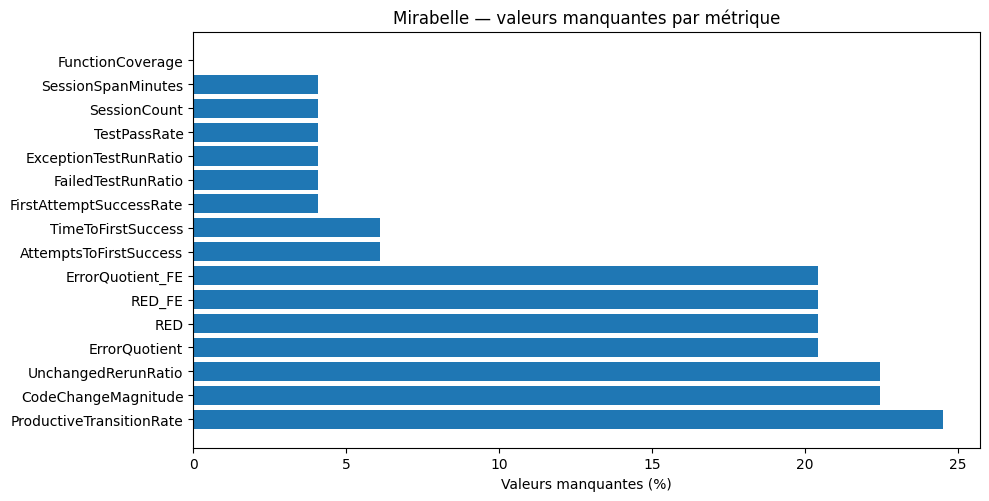

In [4]:
metric_cols = [c for c in features.columns if c != "SubjectID"]
for col in metric_cols:
    features[col] = pd.to_numeric(features[col], errors="coerce")

missing = (
    features[metric_cols].isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("pct_manquant").reset_index().rename(columns={"index": "variable"})
)
display(missing)

display(features[metric_cols].describe().T)

plt.figure(figsize=(10, max(4, 0.32 * len(missing))))
plt.barh(missing["variable"], missing["pct_manquant"])
plt.xlabel("Valeurs manquantes (%)")
plt.title(f"{DATASET} — valeurs manquantes par métrique")
plt.tight_layout()
plt.show()
